In [ ]:
import arviz as az
import pandas as pd
import json
import os

import numpy as np
import diffrax
import matplotlib.pyplot as plt
import matplotlib as mpl

import met_brewer as mb
import seaborn as sns
import jax
import sys

sys.path.append("../")
from utils import *
from plotting_helper_funcs import *

sys.path.append("../models/")
from MM_nonessential_all_diffrax import *

# tell jax to use 64bit floats
jax.config.update("jax_enable_x64", True)

plt.style.use('custom')
mpl.rcParams['figure.autolayout'] = True

ValueError: A colormap named "cet_gray" is already registered.

Set up: Models, data, etc.

In [116]:
sampler = "Pathfinder"

plot_color = '#175449'

model = "MM_nonessential_all"
model_info_file = '../models/MM_nonessential_all.json'

data_dir = '../../../results/param_est/kinase_KO/std_dcr/'
save_dir_base = '../../../results/param_est/predictions/stimulus_strength/'

save_dir = save_dir_base + model + '/'
if not os.path.exists(save_dir):
    os.makedirs(save_dir)

# load the model info
with open(model_info_file, 'r') as f:
    model_info = json.load(f)

state_names = list(model_info["init_conds"].keys())
ampkar_states = model_info['ampkar_states']
pampkar_states = model_info['pampkar_states']
y0 = list(model_info["init_conds"].values())

param_names = model_info["params"]


# get the indices of the states
ampkar_idxs = [state_names.index(item) for item in ampkar_states]
pampkar_idxs = [state_names.index(item) for item in pampkar_states]
pampk_idxs = np.array([10, 15, 16]) # exclude AMP-pAMPK

# parameters for the metabolic model
metab_params_file = '../models/metabolism_params_Coccimiglio.json'
with open(metab_params_file, 'r') as file:
        metab_params = json.load(file)

basal_params = list(metab_params["metab_params_basal"].values())
stress_params = list(metab_params["metab_params_stress"].values()) # this is what we can modify to change the stimulus strength
k_gly_idx = list(metab_params["metab_params_basal"].keys()).index("kGly")
k_hydro_idx = list(metab_params["metab_params_basal"].keys()).index("kHydro")


# idata
idata_cyto = az.from_netcdf(data_dir + model + '_cyto_mcmc_samples_' + sampler + '.nc')

# load data to get simulation time
_, _, times = load_data('../../../Schmitt_et_al_2022_data/fig_2e_cyto.npz', 
                        to_seconds=True, constant_std=False)

times = np.linspace(times[0], 1800, 1000)

rtol = 1e-6
atol = 1e-6
evnt_rtol = 1e-12
evnt_atol = 1e-12
pcoeff = 0.3
icoeff = 0.4
dcoeff = 0.0
tmax_init = 1e3

ca_index = list(model_info["init_conds"].keys()).index("Ca")
total_AMPKAR = model_info["init_conds"]["AMPKAR"]

width = 1.5
height = 1.25

Write a function to run all simulations and return the results. It takes the desired 
stimuli as the inputs

In [117]:
# func to compute time to half max
# calculate time to half max of pAMPKAR_stressed/AMPKAR_stressed
def compute_half_max(arr):
    tmp = arr - arr[0]
    max_val = tmp.max()
    max_val_idx = jnp.where(tmp == max_val)[0][0] # find the index of the max value

    # find the index of the half max value

    half_max = max_val / 2
    half_max_idx = jnp.argmin(jnp.abs(tmp[0:(max_val_idx+1)]- half_max))

    return half_max_idx

def run_model_sims(stims, idata, nsamples=4):
    """ stims should be a 3-tuple of lists (k_gly, k_hydro, Ca2+)"""

    # unpack stimuli
    k_gly, k_hydro, Ca2 = stims

    # check that the lengths are the same
    if not (len(k_gly) == len(k_hydro) == len(Ca2)):
        raise ValueError("Lengths of k_gly, k_hydro, and Ca2 must be the same.")

    rhs = eval(model + '(' + ','.join(str(elm) for elm in basal_params) \
            + ')')
    rhs = diffrax.ODETerm(rhs)
    
    # get params from the idata
    params = get_param_subsample(param_names, idata, nsamples)
   
    stress_sols = []
    for i in range(len(k_gly)):
        k_gly_i = k_gly[i]
        k_hydro_i = k_hydro[i]
        Ca2_i = Ca2[i]

        print(k_gly_i, k_hydro_i, Ca2_i)

        # get the params for the current stimulus strength

        stress_params_mod = stress_params.copy()
        stress_params_mod[k_gly_idx] = k_gly_i # update k_gly
        stress_params_mod[k_hydro_idx] = k_hydro_i

        # get the rhs for the current stimulus strength
        rhs_stress = eval(model + '(' + ','.join(str(elm) for elm in stress_params_mod) \
            + ')')
        
        rhs_stress = diffrax.ODETerm(rhs_stress)

        ca_stress = jnp.array([Ca2_i,])

        # run the stress sims
        tmp = []
        for j in range(params.shape[0]):
            sol_stressed, _ = solve_traj_timeDepCaMKK(rhs, rhs_stress, y0,
                ca_stress, ca_index, params[j], times, tmax_init=1e3, rtol=1e-6,
                atol=1e-6, pcoeff=0.3, icoeff=0.4, dcoeff=0.0, dt0=1e-10)

            # compute pAMPKAR/AMPKAR_tot
            pAMPKAR_stressed = sol_stressed[jnp.array(pampkar_idxs), :].sum(axis=0)
            pAMPK_stressed = sol_stressed[jnp.array(pampk_idxs), :].sum(axis=0)
            tmp.append((pAMPKAR_stressed / total_AMPKAR, sol_stressed))

        stress_sols.append(tmp)
    
    return stress_sols, params

def plot_barplot(data_df, x_name, y_name, x_label, y_label, fig_width, fig_height, 
                 plot_color, invert_x=False, xticklabs=None,
                               rot_angle=0):
    fig, ax = get_sized_fig_ax(fig_width, fig_height)

    sns.barplot(data=data_df, x=x_name, y=y_name, 
            color=plot_color, ax=ax, edgecolor='black', alpha=0.75,
            errorbar='sd',err_kws={'color': 'black'})
    if invert_x:
        ax.invert_xaxis()
    
    ax.set_xlabel(x_label, fontsize=10)
    ax.set_ylabel(y_label, fontsize=10)

    if xticklabs is not None:
        ax.set_xticklabels(xticklabs, fontsize=8, rotation=rot_angle)
    else:
        ax.set_xticklabels(ax.get_xticklabels(), fontsize=8, rotation=rot_angle)
    
    ax.tick_params(axis='both', which='major', labelsize=8)


    return fig, ax



Now actually run this. There is also the option to load previous results if they exist.

First, vary only the rate of ATP production. Fixing Ca_stress to 0.25 and kHydro to the default

Now process the results. Compute maximums and time to half maxes.

Plots

In [118]:
stims = (
    [0.4, 0.3, 0.2, 0.1, 0.075, 0.05, 0.025, 0.01, 0.005], # k_gly
    [0.15, 0.15, 0.15, 0.15,0.15, 0.15, 0.15, 0.15, 0.15], # k_hydro
    [0.25, 0.25, 0.25, 0.25,0.25, 0.25, 0.25, 0.25, 0.25], # Ca2+
)

xticklabs = [str(round(stim/0.5, 2)) for stim in stims[0]]

nsamples = 40
# run and save the simulations
sol_kGly_only = run_model_sims(stims, idata_cyto, nsamples=nsamples)
# np.save(save_dir + 'vary_kGly_only.np', sol_kGly_only)

print("Finished running simulations!")

sol_kGly_only, params = sol_kGly_only

pampk_idxs = np.array([10, 15, 16])

sol_AMPKAR = np.zeros((len(stims[0]), nsamples, len(times)))
sol_AMPK = np.zeros((len(stims[0]), nsamples, len(times)))

for i in range(len(stims[0])):
    for j in range(nsamples):
        # get the max value and time to half max for each stimulus strength
        sol_AMPKAR[i,j,:] = sol_kGly_only[i][j][0]
        # sol_AMPK[i,j,:] = sol_kGly_only[i][j][1][jnp.array(pampk_idxs), :].sum(axis=0)
        sol_AMPK[i,j,:] = sol_kGly_only[i][j][1][jnp.array(pampk_idxs), :].sum(axis=0)*params[j][12] + \
                        sol_kGly_only[i][j][1][14, :]*params[j][12]*params[j][24]
        
        # print(params[j][12], params[j][24])

sol_AMPKAR = np.array(sol_AMPKAR)
sol_AMPK = np.array(sol_AMPK)

# Compute AMPKAR and pAMPK-activity max and time to half max
# AMPKAR
max_val_cyto_ampkar = []
t_half_max_cyto_ampkar = []

for i in range(len(stims[0])):
    # get the max value and time to half max for each stimulus strength
    max_val_cyto_ampkar.append(sol_AMPKAR[i].max(axis=1))

    # compute time to half max
    t_half_idx = np.apply_along_axis(compute_half_max, 1, sol_AMPKAR[i])
    t_half_max_cyto_ampkar.append([times[idx] for idx in t_half_idx])

max_val_cyto_ampkar = np.array(max_val_cyto_ampkar)
t_half_max_cyto_ampkar = np.array(t_half_max_cyto_ampkar)

# pAMPK
max_val_cyto_pampk = []
t_half_max_cyto_pampk = []

for i in range(len(stims[0])):
    # get the max value and time to half max for each stimulus strength
    max_val_cyto_pampk.append(sol_AMPK[i].max(axis=1))

    # compute time to half max
    t_half_idx = np.apply_along_axis(compute_half_max, 1, sol_AMPK[i])
    t_half_max_cyto_pampk.append([times[idx] for idx in t_half_idx])

max_val_cyto_pampk = np.array(max_val_cyto_pampk)
t_half_max_cyto_pampk = np.array(t_half_max_cyto_pampk)


0.4 0.15 0.25
0.3 0.15 0.25
0.2 0.15 0.25
0.1 0.15 0.25
0.075 0.15 0.25
0.05 0.15 0.25
0.025 0.15 0.25
0.01 0.15 0.25
0.005 0.15 0.25
Finished running simulations!


/var/folders/8n/spw3_jx50513cdpgqqxx58cr0000gp/T/ipykernel_6860/1726767024.py:85: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(xticklabs, fontsize=8, rotation=rot_angle)
/var/folders/8n/spw3_jx50513cdpgqqxx58cr0000gp/T/ipykernel_6860/1926601316.py:14: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.savefig(save_dir + 'max_vals_cyto_ampkar_kGly_ca_025.pdf', bbox_inches='tight',
/var/folders/8n/spw3_jx50513cdpgqqxx58cr0000gp/T/ipykernel_6860/1726767024.py:85: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(xticklabs, fontsize=8, rotation=rot_angle)
/var/folders/8n/spw3_jx50513cdpgqqxx58cr0000gp/T/ipykernel_6860/1926601316.py:28: UserWarning: This figure includes Axes that are not compatible with tight_layout, so resu

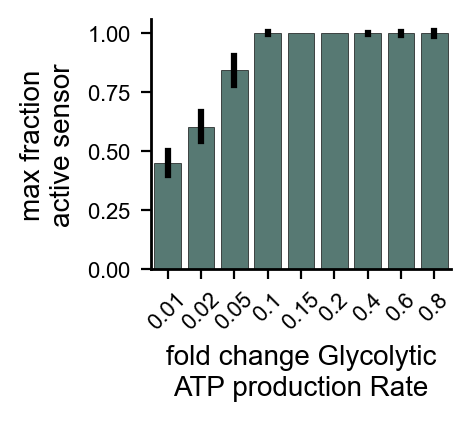

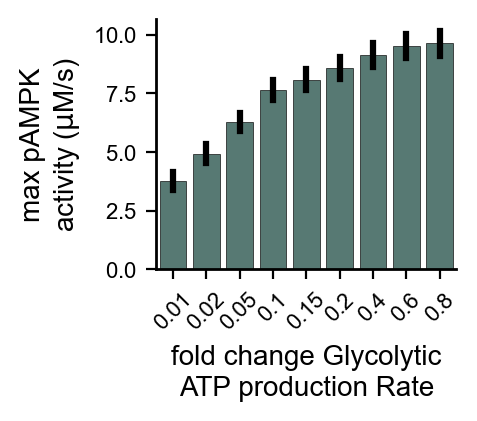

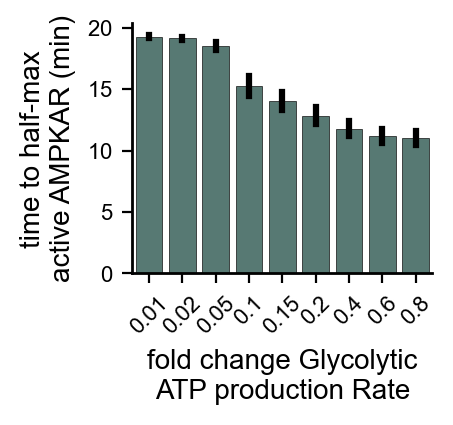

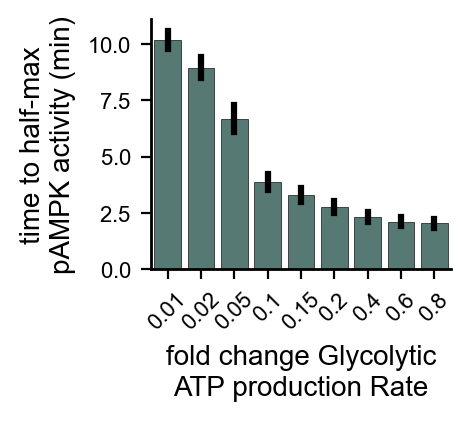

In [119]:
# plot ampkar max activity vs pAMPK max activity
# max vals
# AMPKAR
df_max_vals = pd.DataFrame({
    'param': np.repeat(stims[0], max_val_cyto_ampkar.shape[1]),
    'replicate': np.tile(np.arange(max_val_cyto_ampkar.shape[1]), len(stims[0])),
    'max_fraction_active': max_val_cyto_ampkar.flatten()
})
fig, ax = plot_barplot(df_max_vals, 'param', 'max_fraction_active', 
             'fold change Glycolytic\nATP production Rate', 
             'max fraction\nactive sensor', width, height, 
                 plot_color, invert_x=True, xticklabs=xticklabs,
                               rot_angle=45)
fig.savefig(save_dir + 'max_vals_cyto_ampkar_kGly_ca_025.pdf', bbox_inches='tight',
            transparent=True)

# pAMPK
df_max_vals = pd.DataFrame({
    'param': np.repeat(stims[0], max_val_cyto_pampk.shape[1]),
    'replicate': np.tile(np.arange(max_val_cyto_pampk.shape[1]), len(stims[0])),
    'max_fraction_active': max_val_cyto_pampk.flatten()*1000
})
fig, ax = plot_barplot(df_max_vals, 'param', 'max_fraction_active', 
             'fold change Glycolytic\nATP production Rate', 
             'max pAMPK\nactivity '+r'($\mu$M/s)', width, height, 
                 plot_color, invert_x=True, xticklabs=xticklabs,
                               rot_angle=45)
fig.savefig(save_dir + 'max_vals_cyto_pAMPK_kGly_ca_025.pdf', bbox_inches='tight',
            transparent=True)

# time to half max
# AMPKAR
df_max_vals = pd.DataFrame({
    'param': np.repeat(stims[0], t_half_max_cyto_ampkar.shape[1]),
    'replicate': np.tile(np.arange(t_half_max_cyto_ampkar.shape[1]), len(stims[0])),
    't-half-max': t_half_max_cyto_ampkar.flatten()/60
})
fig, ax = plot_barplot(df_max_vals, 'param', 't-half-max', 
             'fold change Glycolytic\nATP production Rate', 
             'time to half-max\nactive AMPKAR (min)', width, height, 
                 plot_color, invert_x=True, xticklabs=xticklabs,
                               rot_angle=45)
fig.savefig(save_dir + 't_half_max_ampkar_kGly_ca_025.pdf', bbox_inches='tight',
            transparent=True)

# pAMPK
df_max_vals = pd.DataFrame({
    'param': np.repeat(stims[0], t_half_max_cyto_pampk.shape[1]),
    'replicate': np.tile(np.arange(t_half_max_cyto_pampk.shape[1]), len(stims[0])),
    't-half-max': t_half_max_cyto_pampk.flatten()/60
})
fig, ax = plot_barplot(df_max_vals, 'param', 't-half-max', 
             'fold change Glycolytic\nATP production Rate', 
             'time to half-max\npAMPK activity (min)', width, height, 
                 plot_color, invert_x=True, xticklabs=xticklabs,
                               rot_angle=45)
fig.savefig(save_dir + 't_half_max_pAMPK_kGly_ca_025.pdf', bbox_inches='tight',
            transparent=True)


Plot scatter plots that show relaionship between AMPKAR response and pAMPK response

/var/folders/8n/spw3_jx50513cdpgqqxx58cr0000gp/T/ipykernel_6860/112612086.py:34: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig_cbar.savefig(save_dir + 'scatter_colorbar.pdf', bbox_inches='tight')
/var/folders/8n/spw3_jx50513cdpgqqxx58cr0000gp/T/ipykernel_6860/112612086.py:37: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.savefig(save_dir + 'scatter_cyto_ampkar_pAMPK_kGly_ca_025.pdf', bbox_inches='tight',
/var/folders/8n/spw3_jx50513cdpgqqxx58cr0000gp/T/ipykernel_6860/112612086.py:59: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.savefig(save_dir + 'scatter_t_half_max_cyto_ampkar_pAMPK_kGly_ca_025.pdf', bbox_inches='tight',
/Users/natetest/miniforge3/envs/pymc/lib/python3.13/site-packages/IPython/core/events.py:82: UserWarning: This figure includes Axes 

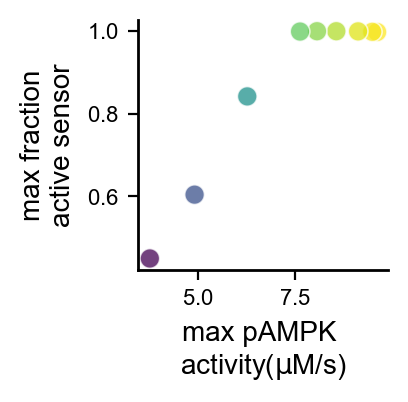

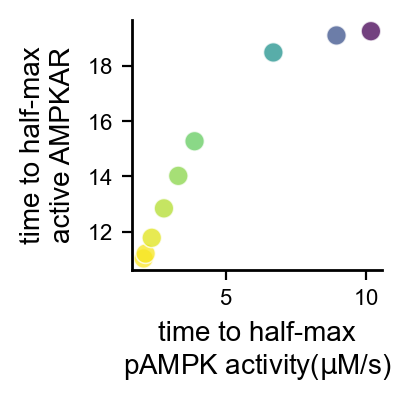

In [120]:
df_max_vals = pd.DataFrame({
    'param': np.repeat(np.array(stims[0])/0.5, max_val_cyto_ampkar.shape[1]),
    'replicate': np.tile(np.arange(max_val_cyto_ampkar.shape[1]), len(stims[0])),
    'ampkar': max_val_cyto_ampkar.flatten(),
    'pAMPK': max_val_cyto_pampk.flatten()*1000
})

fig, ax = get_sized_fig_ax(1.25, height)
scatter = sns.scatterplot(data=df_max_vals.groupby('param', as_index=False).mean(), 
                          x='pAMPK', y='ampkar', hue='param',
                          palette='viridis_r', ax=ax, alpha=0.75, s=50, legend=False)
norm = plt.Normalize(df_max_vals['param'].min(), df_max_vals['param'].max())
sm = plt.cm.ScalarMappable(cmap='viridis_r', norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, aspect=20, shrink=0.2)
cbar.ax.tick_params(labelsize=8)
cbar.set_label('fold change Glycolytic\nATP production rate', fontsize=10)

ax.tick_params(axis='both', which='major', labelsize=8)
ax.ticklabel_format(style='plain', axis='both')

ax.set_xlabel('max pAMPK \nactivity'+ r'($\mu$M/s)', fontsize=10)
ax.set_ylabel('max fraction\nactive sensor', fontsize=10)

# Remove colorbar from this figure
cbar.remove()

# Create a standalone colorbar and save as PDF
fig_cbar, ax_cbar = plt.subplots(figsize=(0.3, 1.5))
fig_cbar.subplots_adjust(left=0.5, right=0.8)
cb = plt.colorbar(sm, cax=ax_cbar)
cb.ax.tick_params(labelsize=8)
cb.set_label('fold change Glycolytic\nATP production rate', fontsize=8)
fig_cbar.savefig(save_dir + 'scatter_colorbar.pdf', bbox_inches='tight')
plt.close(fig_cbar)

fig.savefig(save_dir + 'scatter_cyto_ampkar_pAMPK_kGly_ca_025.pdf', bbox_inches='tight',
            transparent=True)

df_t_half = pd.DataFrame({
    'param': np.repeat(np.array(stims[0])/0.5, t_half_max_cyto_ampkar.shape[1]),
    'replicate': np.tile(np.arange(t_half_max_cyto_ampkar.shape[1]), len(stims[0])),
    'ampkar': t_half_max_cyto_ampkar.flatten()/60,
    'pAMPK': t_half_max_cyto_pampk.flatten()/60
})

fig, ax = get_sized_fig_ax(1.25, height)
scatter = sns.scatterplot(data=df_t_half.groupby('param', as_index=False).mean(), 
                          x='pAMPK', y='ampkar', hue='param',
                          palette='viridis_r', ax=ax, alpha=0.75, s=50, legend=False)
norm = plt.Normalize(df_max_vals['param'].min(), df_max_vals['param'].max())

ax.tick_params(axis='both', which='major', labelsize=8)
ax.ticklabel_format(style='plain', axis='both')

ax.set_xlabel('time to half-max\npAMPK activity'+ r'($\mu$M/s)', fontsize=10)
ax.set_ylabel('time to half-max\nactive AMPKAR', fontsize=10)

fig.savefig(save_dir + 'scatter_t_half_max_cyto_ampkar_pAMPK_kGly_ca_025.pdf', bbox_inches='tight',
            transparent=True)

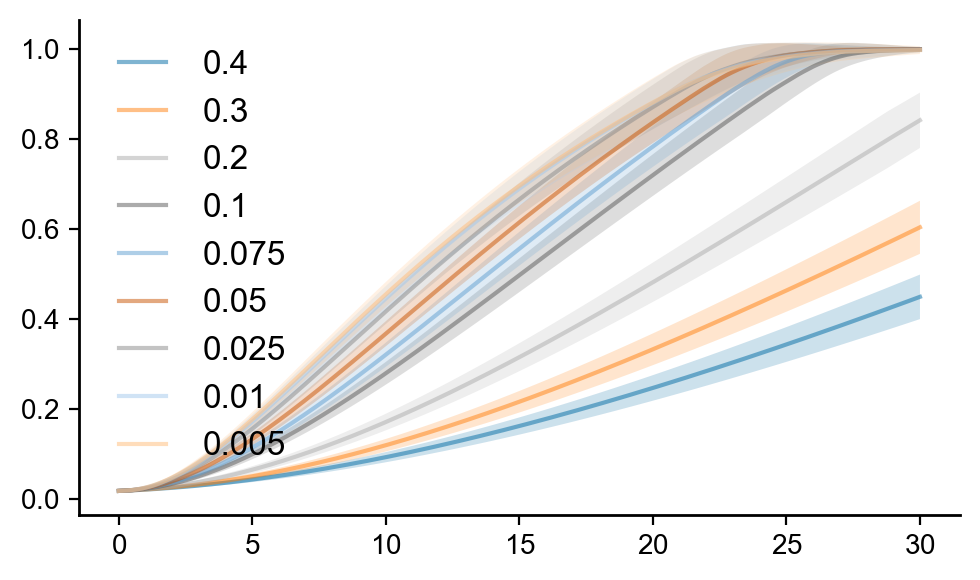

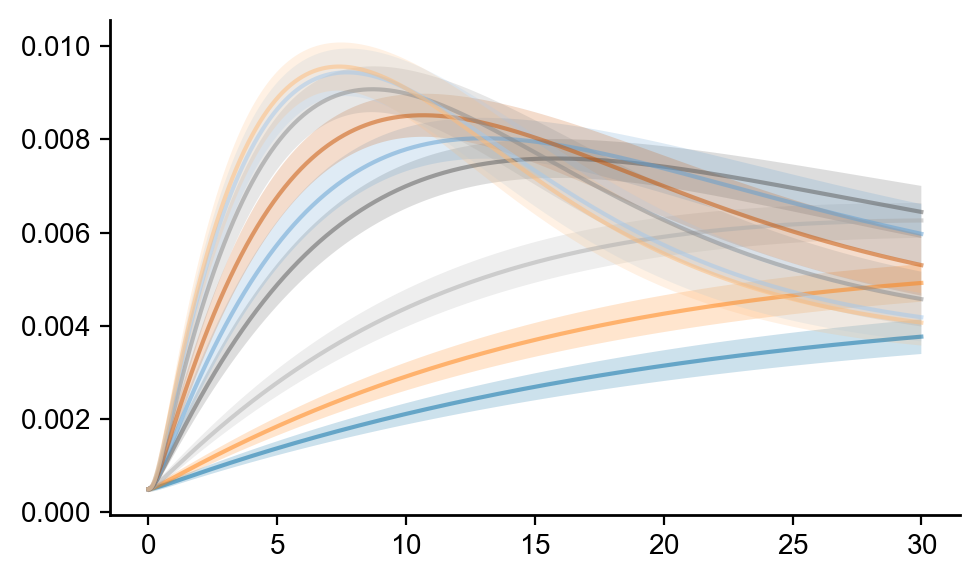

In [121]:
fig, ax = plt.subplots(1, 1, figsize=(5, 3))
for i in range(len(stims[0])):
    ax.plot(times/60, sol_AMPKAR[i].mean(axis=0), alpha=0.5, label=str(stims[0][i]))
    ax.fill_between(times/60, sol_AMPKAR[i].mean(axis=0) - sol_AMPKAR[i].std(axis=0),
                    sol_AMPKAR[i].mean(axis=0) + sol_AMPKAR[i].std(axis=0), alpha=0.2, label='')
    
ax.legend()
    
fig, ax = plt.subplots(1, 1, figsize=(5, 3))
for i in range(len(stims[0])):
    ax.plot(times/60, sol_AMPK[i].mean(axis=0), alpha=0.5)
    ax.fill_between(times/60, sol_AMPK[i].mean(axis=0) - sol_AMPK[i].std(axis=0),
                    sol_AMPK[i].mean(axis=0) + sol_AMPK[i].std(axis=0), alpha=0.2) 

Now vary kHydro alone - fix Ca to basal

In [122]:
import pandas as pd

fold_changes = np.array([1.1, 1.25, 1.5, 2.5, 5, 10, 20])

stims = (
    0.5*np.ones_like(fold_changes), # k_gly
    0.15*fold_changes, # k_hydro
    0.1*np.ones_like(fold_changes), # Ca2+
)

xticklabs = [str(f_change) for f_change in fold_changes]

nsamples = 40
# run and save the simulations
sol_kHydro_only = run_model_sims(stims, idata_cyto, nsamples=nsamples)
# np.save(save_dir + 'vary_kHydro_only.np', sol_kHydro_only)

print("Finished running simulations!")

sol_kHydro_only, params = sol_kHydro_only

sol_AMPKAR = np.zeros((len(stims[0]), nsamples, len(times)))
sol_AMPK = np.zeros((len(stims[0]), nsamples, len(times)))

for i in range(len(stims[0])):
    for j in range(nsamples):
        # get the max value and time to half max for each stimulus strength
        sol_AMPKAR[i,j,:] = sol_kHydro_only[i][j][0]
        sol_AMPK[i,j,:] = sol_kHydro_only[i][j][1][jnp.array(pampk_idxs), :].sum(axis=0)*params[j][12] + \
                        sol_kHydro_only[i][j][1][14, :]*params[j][12]*params[j][24]
        
        # print(params[j][12], params[j][24])

sol_AMPKAR = np.array(sol_AMPKAR)
sol_AMPK = np.array(sol_AMPK)

# Compute AMPKAR and pAMPK-activity max and time to half max
# pAMPK
max_val_cyto_pAMPK = []
t_half_max_cyto_pAMPK = []

for i in range(len(stims[0])):
    # get the max value and time to half max for each stimulus strength
    max_val_cyto_pAMPK.append(sol_AMPK[i].max(axis=1))

    # compute time to half max
    t_half_idx = np.apply_along_axis(compute_half_max, 1, sol_AMPK[i])
    t_half_max_cyto_pAMPK.append([times[idx] for idx in t_half_idx])

max_val_cyto_pAMPK = np.array(max_val_cyto_pAMPK)
t_half_max_cyto_pAMPK = np.array(t_half_max_cyto_pAMPK)

# AMPKAR
max_val_cyto_ampkar = []
t_half_max_cyto_ampkar = []

for i in range(len(stims[0])):
    # get the max value and time to half max for each stimulus strength
    max_val_cyto_ampkar.append(sol_AMPKAR[i].max(axis=1))

    # compute time to half max
    t_half_idx = np.apply_along_axis(compute_half_max, 1, sol_AMPKAR[i])
    t_half_max_cyto_ampkar.append([times[idx] for idx in t_half_idx])

max_val_cyto_ampkar = np.array(max_val_cyto_ampkar)
t_half_max_cyto_ampkar = np.array(t_half_max_cyto_ampkar)

0.5 0.165 0.1
0.5 0.1875 0.1
0.5 0.22499999999999998 0.1
0.5 0.375 0.1
0.5 0.75 0.1
0.5 1.5 0.1
0.5 3.0 0.1
Finished running simulations!


/var/folders/8n/spw3_jx50513cdpgqqxx58cr0000gp/T/ipykernel_6860/1726767024.py:85: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(xticklabs, fontsize=8, rotation=rot_angle)
/var/folders/8n/spw3_jx50513cdpgqqxx58cr0000gp/T/ipykernel_6860/532211211.py:18: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.savefig(save_dir + 'max_vals_cyto_pAMPK_kHydro_only.pdf', bbox_inches='tight',
/var/folders/8n/spw3_jx50513cdpgqqxx58cr0000gp/T/ipykernel_6860/1726767024.py:85: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(xticklabs, fontsize=8, rotation=rot_angle)
/var/folders/8n/spw3_jx50513cdpgqqxx58cr0000gp/T/ipykernel_6860/532211211.py:34: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results

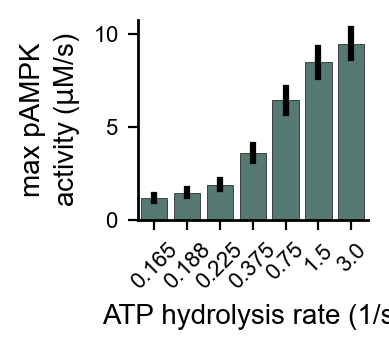

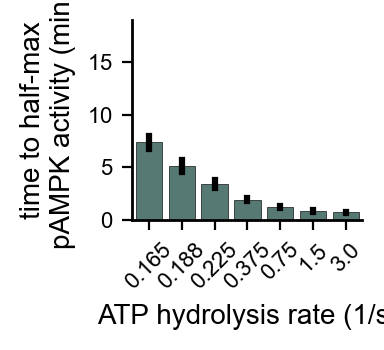

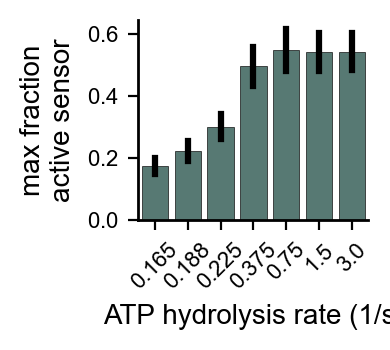

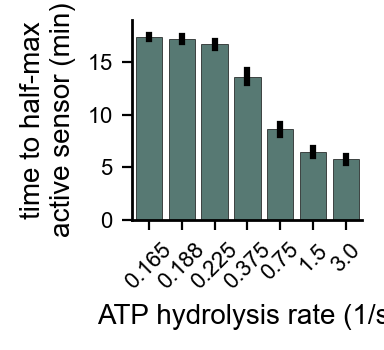

In [123]:
width = 1.15
height = 1.

# # max vals
# pAMPK
xticklabs = [str(round(stim, 3)) for stim in stims[1]]

df_max_vals = pd.DataFrame({
    'param': np.repeat(stims[1], max_val_cyto_pAMPK.shape[1]),
    'replicate': np.tile(np.arange(max_val_cyto_pAMPK.shape[1]), len(stims[0])),
    'max_fraction_active': max_val_cyto_pAMPK.flatten()*1000
})
fig, ax = plot_barplot(df_max_vals, 'param', 'max_fraction_active', 
             'ATP hydrolysis rate (1/s)', 
             'max pAMPK\nactivity '+r'($\mu$M/s)', width, height, 
                 plot_color, invert_x=False, xticklabs=xticklabs,
                               rot_angle=45)
fig.savefig(save_dir + 'max_vals_cyto_pAMPK_kHydro_only.pdf', bbox_inches='tight',
            transparent=True)


# pAMPK
df_max_vals = pd.DataFrame({
    'param': np.repeat(stims[1], t_half_max_cyto_pAMPK.shape[1]),
    'replicate': np.tile(np.arange(t_half_max_cyto_pAMPK.shape[1]), len(stims[0])),
    't-half-max': t_half_max_cyto_pAMPK.flatten()/60
})
fig, ax = plot_barplot(df_max_vals, 'param', 't-half-max', 
             'ATP hydrolysis rate (1/s)', 
             'time to half-max\npAMPK activity (min)', width, height, 
                 plot_color, invert_x=False, xticklabs=xticklabs,
                               rot_angle=45)
ax.set_ylim(0, 19)
fig.savefig(save_dir + 't_half_max_pAMPK_kHydro_only.pdf', bbox_inches='tight',
            transparent=True)

# AMPKAR
df_max_vals = pd.DataFrame({
    'param': np.repeat(stims[1], max_val_cyto_ampkar.shape[1]),
    'replicate': np.tile(np.arange(max_val_cyto_ampkar.shape[1]), len(stims[0])),
    'max_fraction_active': max_val_cyto_ampkar.flatten()
})
fig, ax = plot_barplot(df_max_vals, 'param', 'max_fraction_active', 
             'ATP hydrolysis rate (1/s)', 
             'max fraction\nactive sensor', width, height, 
                 plot_color, invert_x=False, xticklabs=xticklabs,
                               rot_angle=45)
fig.savefig(save_dir + 'max_vals_cyto_ampkar_kHydro_only.pdf', bbox_inches='tight',
            transparent=True)

# AMPKAR
df_max_vals = pd.DataFrame({
    'param': np.repeat(stims[1], t_half_max_cyto_ampkar.shape[1]),
    'replicate': np.tile(np.arange(t_half_max_cyto_ampkar.shape[1]), len(stims[0])),
    't-half-max': t_half_max_cyto_ampkar.flatten()/60
})
fig, ax = plot_barplot(df_max_vals, 'param', 't-half-max', 
             'ATP hydrolysis rate (1/s)', 
             'time to half-max\nactive sensor (min)', width, height, 
                 plot_color, invert_x=False, xticklabs=xticklabs,
                               rot_angle=45)
ax.set_ylim(0, 19)
fig.savefig(save_dir + 't_half_max_ampkar_kHydro_only.pdf', bbox_inches='tight',
            transparent=True)

/var/folders/8n/spw3_jx50513cdpgqqxx58cr0000gp/T/ipykernel_6860/805315828.py:34: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  fig_cbar.savefig(save_dir + 'ATP_hydro_scatter_colorbar.pdf', bbox_inches='tight')
/var/folders/8n/spw3_jx50513cdpgqqxx58cr0000gp/T/ipykernel_6860/805315828.py:37: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.savefig(save_dir + 'scatter_cyto_ampkar_pAMPK_kHydro_only.pdf', bbox_inches='tight',
/var/folders/8n/spw3_jx50513cdpgqqxx58cr0000gp/T/ipykernel_6860/805315828.py:64: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.savefig(save_dir + 'scatter_t_half_max_cyto_ampkar_pAMPK_kHydro_only.pdf', bbox_inches='tight',
/Users/natetest/miniforge3/envs/pymc/lib/python3.13/site-packages/IPython/core/events.py:82: UserWarning: This figure incl

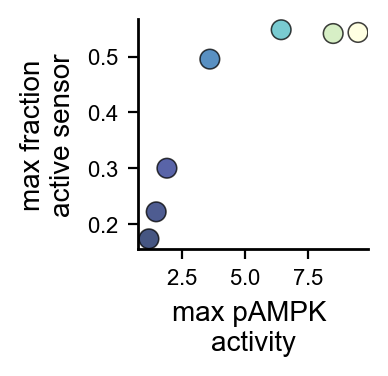

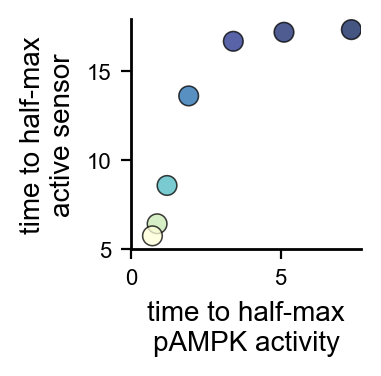

In [124]:
df_max_vals = pd.DataFrame({
    'param': np.repeat(np.log(np.array(stims[1])), max_val_cyto_ampkar.shape[1]),
    'replicate': np.tile(np.arange(max_val_cyto_ampkar.shape[1]), len(stims[1])),
    'ampkar': max_val_cyto_ampkar.flatten(),
    'pAMPK': max_val_cyto_pAMPK.flatten()*1000
})

fig, ax = get_sized_fig_ax(width, width)
scatter = sns.scatterplot(data=df_max_vals.groupby('param', as_index=False).mean(), 
                          x='pAMPK', y='ampkar', hue='param', edgecolor='black',
                          palette='YlGnBu_r', ax=ax, alpha=0.75, s=50, legend=False)
norm = plt.Normalize(df_max_vals['param'].min(), df_max_vals['param'].max())
sm = plt.cm.ScalarMappable(cmap='YlGnBu_r', norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, aspect=20, shrink=0.2)
cbar.ax.tick_params(labelsize=8)
cbar.set_label('log ATP\nhydrolysis rate', fontsize=10)

ax.tick_params(axis='both', which='major', labelsize=8)
ax.ticklabel_format(style='plain', axis='both')

ax.set_xlabel('max pAMPK \nactivity', fontsize=10)
ax.set_ylabel('max fraction\nactive sensor', fontsize=10)

# Remove colorbar from this figure
cbar.remove()

# Create a standalone horizontal colorbar and save as PDF
fig_cbar, ax_cbar = plt.subplots(figsize=(1.5, 0.3))
fig_cbar.subplots_adjust(bottom=0.5, top=0.8)
cb = plt.colorbar(sm, cax=ax_cbar, orientation='horizontal')
cb.ax.tick_params(labelsize=8)
cb.set_label('log ATP hydrolysis rate', fontsize=8)
fig_cbar.savefig(save_dir + 'ATP_hydro_scatter_colorbar.pdf', bbox_inches='tight')
plt.close(fig_cbar)

fig.savefig(save_dir + 'scatter_cyto_ampkar_pAMPK_kHydro_only.pdf', bbox_inches='tight',
            transparent=True)

df_t_half = pd.DataFrame({
    'param': np.repeat(np.log(np.array(stims[1])), t_half_max_cyto_ampkar.shape[1]),
    'replicate': np.tile(np.arange(t_half_max_cyto_ampkar.shape[1]), len(stims[1])),
    'ampkar': t_half_max_cyto_ampkar.flatten()/60,
    'pAMPK': t_half_max_cyto_pAMPK.flatten()/60
})

fig, ax = get_sized_fig_ax(width, width)
scatter = sns.scatterplot(data=df_t_half.groupby('param', as_index=False).mean(), 
                          x='pAMPK', y='ampkar', hue='param', edgecolor='black',
                          palette='YlGnBu_r', ax=ax, alpha=0.75, s=50, legend=False)
norm = plt.Normalize(df_max_vals['param'].min(), df_max_vals['param'].max())

ax.tick_params(axis='both', which='major', labelsize=8)
ax.ticklabel_format(style='plain', axis='both')

ax.set_xlabel('time to half-max\npAMPK activity', fontsize=10)
ax.set_ylabel('time to half-max\nactive sensor', fontsize=10)

ax.set_yticks([5, 10, 15])
ax.set_yticklabels([5, 10, 15], fontsize=8)
ax.set_xticks([0, 5])
ax.set_xticklabels([0, 5], fontsize=8)

fig.savefig(save_dir + 'scatter_t_half_max_cyto_ampkar_pAMPK_kHydro_only.pdf', bbox_inches='tight',
            transparent=True)

Vary Calcium only

In [125]:
fold_changes = np.array([1.1, 2.5, 3, 4, 5, 10, 100])

stims = (
    0.5*np.ones_like(fold_changes), # k_gly
    0.15*np.ones_like(fold_changes), # k_hydro
    0.1*fold_changes, # Ca2+
)

# xticklabs = [str(f_change) for f_change in fold_changes]
xticklabs = [str(round(stim, 3)) for stim in stims[2]]

nsamples = 40

# run and save the simulations
sol_Ca_only = run_model_sims(stims, idata_cyto, nsamples=nsamples)

print("Finished running simulations!")

sol_Ca_only, params = sol_Ca_only
    
sol_AMPKAR = np.zeros((len(stims[0]), nsamples, len(times)))
sol_AMPK = np.zeros((len(stims[0]), nsamples, len(times)))

for i in range(len(stims[0])):
    for j in range(nsamples):
        # get the max value and time to half max for each stimulus strength
        sol_AMPKAR[i,j,:] = sol_Ca_only[i][j][0]
        sol_AMPK[i,j,:] = sol_Ca_only[i][j][1][jnp.array(pampk_idxs), :].sum(axis=0)*params[j][12] + \
                        sol_Ca_only[i][j][1][14, :]*params[j][12]*params[j][24]
        
        # print(params[j][12], params[j][24])

sol_AMPKAR = np.array(sol_AMPKAR)
sol_AMPK = np.array(sol_AMPK)

# Compute AMPKAR and pAMPK-activity max and time to half max
# pAMPK
max_val_cyto_pAMPK = []
t_half_max_cyto_pAMPK = []

for i in range(len(stims[0])):
    # get the max value and time to half max for each stimulus strength
    max_val_cyto_pAMPK.append(sol_AMPK[i].max(axis=1))

    # compute time to half max
    t_half_idx = np.apply_along_axis(compute_half_max, 1, sol_AMPK[i])
    t_half_max_cyto_pAMPK.append([times[idx] for idx in t_half_idx])

max_val_cyto_pAMPK = np.array(max_val_cyto_pAMPK)
t_half_max_cyto_pAMPK = np.array(t_half_max_cyto_pAMPK)

# AMPKAR
max_val_cyto_ampkar = []
t_half_max_cyto_ampkar = []

for i in range(len(stims[0])):
    # get the max value and time to half max for each stimulus strength
    max_val_cyto_ampkar.append(sol_AMPKAR[i].max(axis=1))

    # compute time to half max
    t_half_idx = np.apply_along_axis(compute_half_max, 1, sol_AMPKAR[i])
    t_half_max_cyto_ampkar.append([times[idx] for idx in t_half_idx])

max_val_cyto_ampkar = np.array(max_val_cyto_ampkar)
t_half_max_cyto_ampkar = np.array(t_half_max_cyto_ampkar)

0.5 0.15 0.11000000000000001
0.5 0.15 0.25
0.5 0.15 0.30000000000000004
0.5 0.15 0.4
0.5 0.15 0.5
0.5 0.15 1.0
0.5 0.15 10.0
Finished running simulations!


/var/folders/8n/spw3_jx50513cdpgqqxx58cr0000gp/T/ipykernel_6860/1726767024.py:85: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(xticklabs, fontsize=8, rotation=rot_angle)
/var/folders/8n/spw3_jx50513cdpgqqxx58cr0000gp/T/ipykernel_6860/2278445631.py:14: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.savefig(save_dir + 'max_vals_cyto_pAMPK_Ca_only.pdf', bbox_inches='tight',
/var/folders/8n/spw3_jx50513cdpgqqxx58cr0000gp/T/ipykernel_6860/1726767024.py:85: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(xticklabs, fontsize=8, rotation=rot_angle)
/var/folders/8n/spw3_jx50513cdpgqqxx58cr0000gp/T/ipykernel_6860/2278445631.py:30: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results m

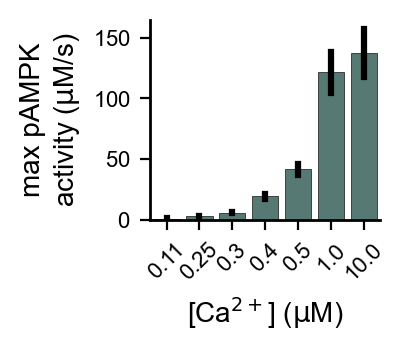

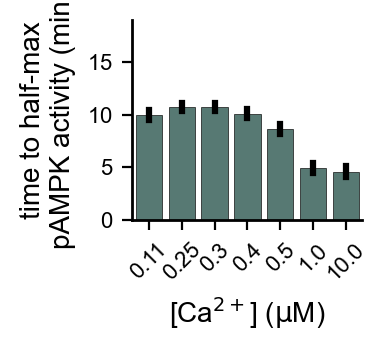

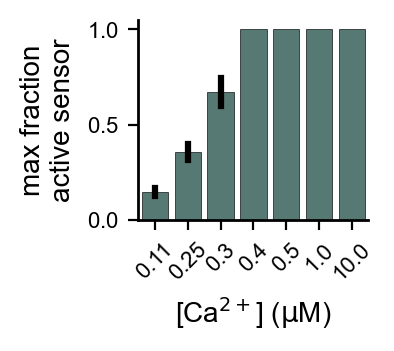

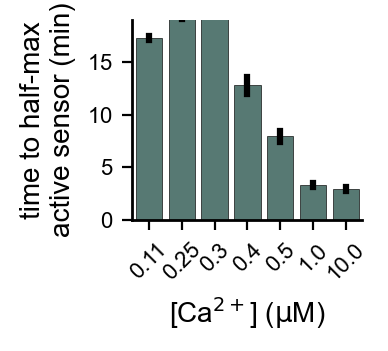

In [126]:
xticklabs = [str(round(stim, 3)) for stim in stims[2]]
# # max vals
# pAMPK
df_max_vals = pd.DataFrame({
    'param': np.repeat(stims[2], max_val_cyto_pAMPK.shape[1]),
    'replicate': np.tile(np.arange(max_val_cyto_pAMPK.shape[1]), len(stims[0])),
    'max_fraction_active': max_val_cyto_pAMPK.flatten()*1000
})
fig, ax = plot_barplot(df_max_vals, 'param', 'max_fraction_active', 
             r'[Ca$^{2+}$] ($\mu$M)', 
             'max pAMPK\nactivity '+r'($\mu$M/s)', width, height, 
                 plot_color, invert_x=False, xticklabs=xticklabs,
                               rot_angle=45)
fig.savefig(save_dir + 'max_vals_cyto_pAMPK_Ca_only.pdf', bbox_inches='tight',
            transparent=True)


# pAMPK
df_max_vals = pd.DataFrame({
    'param': np.repeat(stims[2], t_half_max_cyto_pAMPK.shape[1]),
    'replicate': np.tile(np.arange(t_half_max_cyto_pAMPK.shape[1]), len(stims[0])),
    't-half-max': t_half_max_cyto_pAMPK.flatten()/60
})
fig, ax = plot_barplot(df_max_vals, 'param', 't-half-max', 
             r'[Ca$^{2+}$] ($\mu$M)', 
             'time to half-max\npAMPK activity (min)', width, height, 
                 plot_color, invert_x=False, xticklabs=xticklabs,
                               rot_angle=45)
ax.set_ylim(0, 19)
fig.savefig(save_dir + 't_half_max_pAMPK_Ca_only.pdf', bbox_inches='tight',
            transparent=True)

# AMPKAR
df_max_vals = pd.DataFrame({
    'param': np.repeat(stims[2], max_val_cyto_ampkar.shape[1]),
    'replicate': np.tile(np.arange(max_val_cyto_ampkar.shape[1]), len(stims[0])),
    'max_fraction_active': max_val_cyto_ampkar.flatten()
})

fig, ax = plot_barplot(df_max_vals, 'param', 'max_fraction_active', 
             r'[Ca$^{2+}$] ($\mu$M)', 
             'max fraction\nactive sensor', width, height, 
                 plot_color, invert_x=False, xticklabs=xticklabs,
                               rot_angle=45)
fig.savefig(save_dir + 'max_vals_cyto_ampkar_Ca_only.pdf', bbox_inches='tight',
            transparent=True)

# AMPKAR
df_max_vals = pd.DataFrame({
    'param': np.repeat(stims[2], t_half_max_cyto_ampkar.shape[1]),
    'replicate': np.tile(np.arange(t_half_max_cyto_ampkar.shape[1]), len(stims[0])),
    't-half-max': t_half_max_cyto_ampkar.flatten()/60
})

fig, ax = plot_barplot(df_max_vals, 'param', 't-half-max',
                r'[Ca$^{2+}$] ($\mu$M)', 
                'time to half-max\nactive sensor (min)', width, height, 
                    plot_color, invert_x=False, xticklabs=xticklabs,
                                rot_angle=45)
ax.set_ylim(0, 19)
fig.savefig(save_dir + 't_half_max_ampkar_Ca_only.pdf', bbox_inches='tight',
            transparent=True)

/var/folders/8n/spw3_jx50513cdpgqqxx58cr0000gp/T/ipykernel_6860/1076799861.py:34: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  fig_cbar.savefig(save_dir + 'Ca_scatter_colorbar.pdf', bbox_inches='tight')
/var/folders/8n/spw3_jx50513cdpgqqxx58cr0000gp/T/ipykernel_6860/1076799861.py:37: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.savefig(save_dir + 'scatter_cyto_ampkar_pAMPK_Ca_only.pdf', bbox_inches='tight',
/var/folders/8n/spw3_jx50513cdpgqqxx58cr0000gp/T/ipykernel_6860/1076799861.py:64: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.savefig(save_dir + 'scatter_t_half_max_cyto_ampkar_pAMPK_Ca_only.pdf', bbox_inches='tight',
/Users/natetest/miniforge3/envs/pymc/lib/python3.13/site-packages/IPython/core/events.py:82: UserWarning: This figure includes Axes th

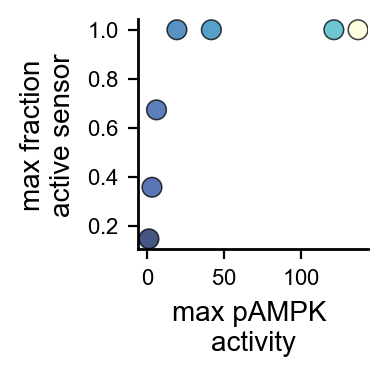

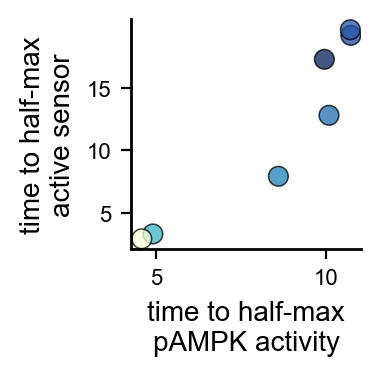

In [127]:
df_max_vals = pd.DataFrame({
    'param': np.repeat(np.log(np.array(stims[2])), max_val_cyto_ampkar.shape[1]),
    'replicate': np.tile(np.arange(max_val_cyto_ampkar.shape[1]), len(stims[2])),
    'ampkar': max_val_cyto_ampkar.flatten(),
    'pAMPK': max_val_cyto_pAMPK.flatten()*1000
})

fig, ax = get_sized_fig_ax(width, width)
scatter = sns.scatterplot(data=df_max_vals.groupby('param', as_index=False).mean(), 
                          x='pAMPK', y='ampkar', hue='param', edgecolor='black',
                          palette='YlGnBu_r', ax=ax, alpha=0.75, s=50, legend=False)
norm = plt.Normalize(df_max_vals['param'].min(), df_max_vals['param'].max())
sm = plt.cm.ScalarMappable(cmap='YlGnBu_r', norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, aspect=20, shrink=0.2)
cbar.ax.tick_params(labelsize=8)
cbar.set_label(r'log [Ca$^{2+}$] ($\mu M$)', fontsize=10)

ax.tick_params(axis='both', which='major', labelsize=8)
ax.ticklabel_format(style='plain', axis='both')

ax.set_xlabel('max pAMPK \nactivity', fontsize=10)
ax.set_ylabel('max fraction\nactive sensor', fontsize=10)

# Remove colorbar from this figure
cbar.remove()

# Create a standalone colorbar and save as PDF
fig_cbar, ax_cbar = plt.subplots(figsize=(1.5, 0.3))
fig_cbar.subplots_adjust(bottom=0.5, top=0.8)
cb = plt.colorbar(sm, cax=ax_cbar, orientation='horizontal')
cb.ax.tick_params(labelsize=8)
cb.set_label(r'log [Ca$^{2+}$] ($\mu M$)', fontsize=8)
fig_cbar.savefig(save_dir + 'Ca_scatter_colorbar.pdf', bbox_inches='tight')
plt.close(fig_cbar)

fig.savefig(save_dir + 'scatter_cyto_ampkar_pAMPK_Ca_only.pdf', bbox_inches='tight',
            transparent=True)

df_t_half = pd.DataFrame({
    'param': np.repeat(np.log(np.array(stims[2])), t_half_max_cyto_ampkar.shape[1]),
    'replicate': np.tile(np.arange(t_half_max_cyto_ampkar.shape[1]), len(stims[2])),
    'ampkar': t_half_max_cyto_ampkar.flatten()/60,
    'pAMPK': t_half_max_cyto_pAMPK.flatten()/60
})

fig, ax = get_sized_fig_ax(width, width)
scatter = sns.scatterplot(data=df_t_half.groupby('param', as_index=False).mean(), 
                          x='pAMPK', y='ampkar', hue='param', edgecolor='black',
                          palette='YlGnBu_r', ax=ax, alpha=0.75, s=50, legend=False)
norm = plt.Normalize(df_max_vals['param'].min(), df_max_vals['param'].max())

ax.tick_params(axis='both', which='major', labelsize=8)
ax.ticklabel_format(style='plain', axis='both')

ax.set_xlabel('time to half-max\npAMPK activity', fontsize=10)
ax.set_ylabel('time to half-max\nactive sensor', fontsize=10)

ax.set_yticks([5, 10, 15])
ax.set_yticklabels([5, 10, 15], fontsize=8)
ax.set_xticks([5, 10])
ax.set_xticklabels([5, 10], fontsize=8)

fig.savefig(save_dir + 'scatter_t_half_max_cyto_ampkar_pAMPK_Ca_only.pdf', bbox_inches='tight',
            transparent=True)

Schmatics of stimuli

/var/folders/8n/spw3_jx50513cdpgqqxx58cr0000gp/T/ipykernel_6860/2057324750.py:14: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.savefig(save_dir + 'fixed.pdf', bbox_inches='tight',
/var/folders/8n/spw3_jx50513cdpgqqxx58cr0000gp/T/ipykernel_6860/2057324750.py:26: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.savefig(save_dir + 'vary.pdf', bbox_inches='tight',


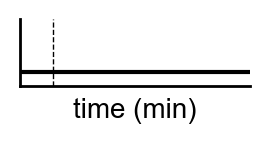

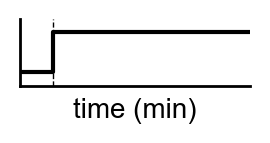

In [149]:
x_vals = np.array([-10, 0, 0, 10, 20, 30])
y_vals_fixed = np.ones_like(x_vals) * 0.35
y_vals_vary = np.array([0.35, 0.35, 0.5, 0.5, 0.5, 0.5])

# fixed
fig, ax = get_sized_fig_ax(width, height/3)
ax.plot(x_vals, y_vals_fixed, color='black')
ax.set_xlim(-5, 30)
ax.set_ylim(0.3, 0.55)
ax.set_xlabel('time (min)', fontsize=10)
ax.axvline(x=0, color='black', linestyle='--', linewidth=0.5)
ax.set_xticks([])
ax.set_yticks([])
fig.savefig(save_dir + 'fixed.pdf', bbox_inches='tight',
            transparent=True)

# vary
fig, ax = get_sized_fig_ax(width, height/3)
ax.plot(x_vals, y_vals_vary, color='black')
ax.set_xlim(-5, 30)
ax.set_ylim(0.3, 0.55)
ax.set_xlabel('time (min)', fontsize=10)
ax.axvline(x=0, color='black', linestyle='--', linewidth=0.5)
ax.set_xticks([])
ax.set_yticks([])
fig.savefig(save_dir + 'vary.pdf', bbox_inches='tight',
            transparent=True)
